# Comparative Explainable Deep Learning for Microplastic Detection and Localisation

**Dataset:** Kaggle — [Microplastic Dataset for Computer Vision](https://www.kaggle.com/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision)  
**Dataset provider:** Panats MP Project  
**Task:** Detect and localise microplastic particles using MPDS bounding-box annotations  
**Ethics alignment:** UREC1/UREC2 low-risk secondary-data workflow with **no human participants**, **no interviews**, **no surveys**, **no personal data**, **no human tissue**, and **no bodily fluids**.

This notebook is designed as a professional, end-to-end Kaggle implementation that matches the approved ethics direction:

1. Load the publicly available secondary Kaggle dataset.
2. Perform detailed exploratory data analysis with charts and annotated images.
3. Prepare an object-detection dataset from `_annotations.csv` files.
4. Train and compare three detection models:
   - Faster R-CNN ResNet50-FPN
   - RetinaNet ResNet50-FPN
   - SSD/SSDLite MobileNetV3
5. Evaluate models using precision, recall, F1-score, IoU, detection-count error, and optional mAP.
6. Produce visual prediction comparisons and explainability-style occlusion sensitivity maps.
7. Export results, figures, metrics, and trained weights to `/kaggle/working/`.

> Important dataset note: the available class label is `Microplastic`, so this project is correctly framed as **microplastic detection and localisation**, not four-class morphology classification.

## 1. Professional project configuration

This section keeps all major paths, model choices, thresholds and training settings in one place. For a faster smoke test, reduce `EPOCHS_PER_MODEL` to `1` and set `MAX_TRAIN_IMAGES` / `MAX_VALID_IMAGES` to a small number. For the final run, keep them as `None` and use the Kaggle GPU.

In [74]:
from __future__ import annotations

# Standard library imports for file handling, timing, reproducibility and exports.
import os
import gc
import csv
import math
import time
import json
import random
import shutil
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

# Data handling and image processing imports.
import numpy as np
import pandas as pd
from PIL import Image

# Visualisation imports used for EDA, annotation checks and prediction plots.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# PyTorch and Torchvision imports for object-detection model training.
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import functional as F
from torchvision.ops import box_iou

# Torchvision detection model factories used for the three-model comparison.
from torchvision.models import ResNet50_Weights, MobileNet_V3_Large_Weights
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    retinanet_resnet50_fpn,
    ssdlite320_mobilenet_v3_large,
)

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=UserWarning)

@dataclass
class ExperimentConfig:
    """Central configuration for a reproducible Kaggle experiment."""
    project_name: str = "microplastic_detection_localisation"
    dataset_root: Path = Path("/kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision")
    output_root: Path = Path("/kaggle/working/microplastic_detection_outputs")
    random_seed: int = 42
    num_classes: int = 2  # Background + Microplastic
    class_name: str = "Microplastic"
    batch_size: int = 2
    num_workers: int = 2
    drop_last_train_batch: bool = True  # Prevents a final batch of size 1, which can break SSDLite BatchNorm layers.
    freeze_batch_norm_for_ssdlite: bool = True  # Keeps SSDLite BatchNorm layers stable on small Kaggle batches.
    epochs_per_model: int = 6
    learning_rate: float = 5e-4
    weight_decay: float = 1e-4
    score_threshold: float = 0.30
    iou_threshold: float = 0.50
    max_train_images: Optional[int] = None   # Example for quick testing: 80
    max_valid_images: Optional[int] = None   # Example for quick testing: 50
    use_pretrained_backbone: bool = True
    train_all_models: bool = True
    save_every_epoch: bool = False
    run_xai: bool = True
    xai_patch_size: int = 64
    xai_stride: int = 64

CONFIG = ExperimentConfig()

# Select GPU automatically when Kaggle GPU acceleration is enabled.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Reproducibility helper for Python, NumPy and PyTorch.
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_global_seed(CONFIG.random_seed)

# Create output folders for figures, model checkpoints, metrics and reports.
FIGURES_DIR = CONFIG.output_root / "figures"
MODELS_DIR = CONFIG.output_root / "models"
METRICS_DIR = CONFIG.output_root / "metrics"
REPORTS_DIR = CONFIG.output_root / "reports"

for directory in [CONFIG.output_root, FIGURES_DIR, MODELS_DIR, METRICS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Save the experiment configuration for reproducibility and dissertation evidence.
with open(CONFIG.output_root / "experiment_config.json", "w") as f:
    json.dump({k: str(v) if isinstance(v, Path) else v for k, v in asdict(CONFIG).items()}, f, indent=4)

print(f"Outputs will be saved to: {CONFIG.output_root}")


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Device: cuda
GPU: Tesla T4
Outputs will be saved to: /kaggle/working/microplastic_detection_outputs


## 2. Dataset discovery and ethics-safe loading

The notebook only reads files from Kaggle's mounted input folder. It does not collect new data, contact participants, scrape personal information, or use human-subject data.

In [75]:
def list_dataset_files(dataset_root: Path, max_files: int = 20) -> None:
    """Check that the Kaggle dataset is mounted and preview a few files."""
    print(f"Dataset root exists: {dataset_root.exists()} -> {dataset_root}")
    if not dataset_root.exists():
        raise FileNotFoundError(
            f"Dataset folder not found: {dataset_root}. "
            "Add the Kaggle dataset to this notebook: imtkaggleteam/microplastic-dataset-for-computer-vision"
        )

    # Walk through the mounted dataset folder to verify images and annotation CSV files are present.
    all_files = []
    for root, _, files in os.walk(dataset_root):
        for filename in files:
            all_files.append(Path(root) / filename)

    print(f"Total files found: {len(all_files):,}")
    print("Sample files:")
    for file_path in all_files[:max_files]:
        print(" -", file_path)

list_dataset_files(CONFIG.dataset_root)


Dataset root exists: True -> /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision
Total files found: 783
Sample files:
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/c--15-_jpg.rf.7b40ed7a869e48e2142b5a37aa10d1f3.jpg
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/c--30-_jpg.rf.dc31d1c1b3a5e0297ea8625cda59cf97.jpg
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/f--11-_jpg.rf.3f002db831a7cff3ff47824394658d2d.jpg
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/c--93-_jpg.rf.6b75dd24411c3ff857686011d4adbb68.jpg
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/c--170-_jpg.rf.c6c10623ecd781ef681ff205c21d35b0.jpg
 - /kaggle/input/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision/valid/c--84-_jpg.rf.57fb8761bfbe6030b7b4b2b46be0787a.jpg
 - /kaggle/input/datasets/i

In [76]:
def load_split_annotations(dataset_root: Path) -> Dict[str, pd.DataFrame]:
    """Load Roboflow-style annotation CSV files from train, valid and test folders."""
    split_to_dataframe: Dict[str, pd.DataFrame] = {}

    # The Kaggle dataset usually contains train and valid folders; test is handled if present.
    for split_name in ["train", "valid", "test"]:
        split_dir = dataset_root / split_name
        csv_path = split_dir / "_annotations.csv"

        if not split_dir.exists() or not csv_path.exists():
            print(f"Skipping split '{split_name}' because folder or _annotations.csv was not found.")
            continue

        # Add split and image_path columns so every annotation row points to its image file.
        dataframe = pd.read_csv(csv_path)
        dataframe["split"] = split_name
        dataframe["image_path"] = dataframe["filename"].apply(lambda x: str(split_dir / x))
        split_to_dataframe[split_name] = dataframe

        print(f"Loaded {split_name}: {len(dataframe):,} annotations, {dataframe['filename'].nunique():,} images")

    if not split_to_dataframe:
        raise FileNotFoundError("No annotation CSV files were found in train/valid/test folders.")

    return split_to_dataframe

# Load all available split-level annotation files into one master table.
split_annotations = load_split_annotations(CONFIG.dataset_root)
all_annotations = pd.concat(split_annotations.values(), ignore_index=True)

print("Annotation columns:")
print(all_annotations.columns.tolist())
print("First five annotation rows:")
display(all_annotations.head())


Loaded train: 5,425 annotations, 577 images
Loaded valid: 1,701 annotations, 204 images
Skipping split 'test' because folder or _annotations.csv was not found.
Annotation columns:
['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'split', 'image_path']
First five annotation rows:


,filename,width,height,class,xmin,ymin,xmax,ymax,split,image_path
0,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,102,170,123,196,train,/kaggle/input/datasets/imtkaggleteam/microplas...
1,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,395,247,424,281,train,/kaggle/input/datasets/imtkaggleteam/microplas...
2,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,160,254,188,290,train,/kaggle/input/datasets/imtkaggleteam/microplas...
3,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,187,307,213,346,train,/kaggle/input/datasets/imtkaggleteam/microplas...
4,177_jpg.rf.78ce205aa324b8cb17ee4051188b13d5.jpg,563,537,Microplastic,175,379,209,427,train,/kaggle/input/datasets/imtkaggleteam/microplas...


## 3. Annotation validation and feature engineering

This section verifies the CSV structure, checks for missing images or invalid boxes, and creates derived variables used in EDA and model evaluation.

In [77]:
def prepare_clean_annotations(annotation_frame: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Validate annotation rows and create the clean_annotations table used throughout the notebook."""
    required_columns = ["filename", "width", "height", "class", "xmin", "ymin", "xmax", "ymax", "split", "image_path"]
    missing_columns = [column for column in required_columns if column not in annotation_frame.columns]
    if missing_columns:
        raise ValueError(f"Missing required annotation columns: {missing_columns}")

    annotations = annotation_frame.copy()

    # Convert coordinate and image-size columns into numeric values for safe calculations.
    for coordinate_column in ["xmin", "ymin", "xmax", "ymax", "width", "height"]:
        annotations[coordinate_column] = pd.to_numeric(annotations[coordinate_column], errors="coerce")

    # Create derived variables used in EDA charts, model validation and report tables.
    annotations["bbox_width"] = annotations["xmax"] - annotations["xmin"]
    annotations["bbox_height"] = annotations["ymax"] - annotations["ymin"]
    annotations["bbox_area"] = annotations["bbox_width"] * annotations["bbox_height"]
    annotations["image_area"] = annotations["width"] * annotations["height"]
    annotations["bbox_area_ratio"] = annotations["bbox_area"] / annotations["image_area"]
    annotations["bbox_aspect_ratio"] = annotations["bbox_width"] / annotations["bbox_height"].replace(0, np.nan)
    annotations["bbox_center_x"] = (annotations["xmin"] + annotations["xmax"]) / 2
    annotations["bbox_center_y"] = (annotations["ymin"] + annotations["ymax"]) / 2
    annotations["bbox_center_x_ratio"] = annotations["bbox_center_x"] / annotations["width"]
    annotations["bbox_center_y_ratio"] = annotations["bbox_center_y"] / annotations["height"]
    annotations["image_exists"] = annotations["image_path"].apply(lambda p: Path(p).exists())

    # Identify rows that cannot be used safely for object-detection training.
    invalid_box_mask = (
        annotations[["xmin", "ymin", "xmax", "ymax", "width", "height"]].isna().any(axis=1)
        | (annotations["bbox_width"] <= 0)
        | (annotations["bbox_height"] <= 0)
        | (annotations["xmin"] < 0)
        | (annotations["ymin"] < 0)
        | (annotations["xmax"] > annotations["width"])
        | (annotations["ymax"] > annotations["height"])
    )

    quality_table = pd.DataFrame({
        "check": [
            "Total annotation rows",
            "Unique images",
            "Unique classes",
            "Missing image files",
            "Invalid bounding boxes",
            "Duplicate annotation rows"
        ],
        "value": [
            len(annotations),
            annotations["filename"].nunique(),
            annotations["class"].nunique(),
            int((~annotations["image_exists"]).sum()),
            int(invalid_box_mask.sum()),
            int(annotations.duplicated(subset=["split", "filename", "xmin", "ymin", "xmax", "ymax", "class"]).sum())
        ]
    })

    clean_table = annotations.loc[~invalid_box_mask & annotations["image_exists"]].copy()
    return clean_table, quality_table

# Build the cleaned annotation table once and reuse it across all EDA/training sections.
clean_annotations, quality_summary = prepare_clean_annotations(all_annotations)

display(quality_summary)
print(f"Clean annotations retained: {len(clean_annotations):,} / {len(all_annotations):,}")
print(f"Classes found: {sorted(clean_annotations['class'].unique().tolist())}")

# Save an audit trail of the cleaned annotation table for reporting and reproducibility.
clean_annotations.to_csv(METRICS_DIR / "clean_annotations_audit.csv", index=False)
quality_summary.to_csv(METRICS_DIR / "annotation_quality_summary.csv", index=False)


,check,value
0,Total annotation rows,7126
1,Unique images,781
2,Unique classes,1
3,Missing image files,0
4,Invalid bounding boxes,0
5,Duplicate annotation rows,0


Clean annotations retained: 7,126 / 7,126
Classes found: ['Microplastic']


## 4. Detailed exploratory data analysis

This EDA is important because the dataset is an object-detection dataset. We need to understand image counts, annotation density, bounding-box sizes, object locations and possible imbalance before model training.

,split,unique_images,annotation_count,average_objects_per_image
0,train,577,5425,9.402080
1,valid,204,1701,8.338235


Saved figure: /kaggle/working/microplastic_detection_outputs/figures/01_split_summary.png


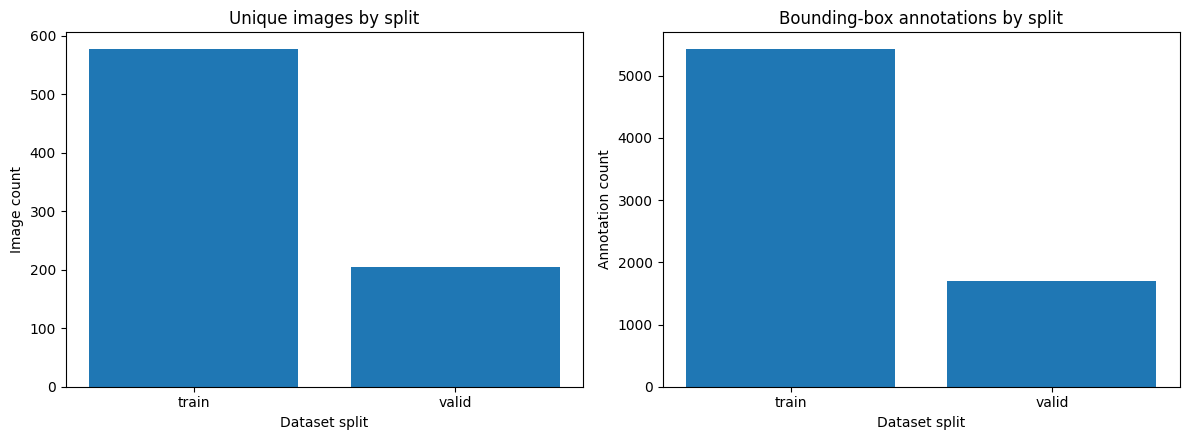

In [78]:
def ensure_clean_annotations_available() -> None:
    """Recreate clean_annotations if this EDA cell is run after a kernel restart or out of order."""
    global split_annotations, all_annotations, clean_annotations, quality_summary

    # If the clean table already exists, the notebook can continue directly.
    if "clean_annotations" in globals() and isinstance(clean_annotations, pd.DataFrame):
        return

    print("clean_annotations was not found, so it will be recreated from the Kaggle annotation CSV files.")

    # Reload raw annotations if the previous loading cell was not executed.
    if "all_annotations" not in globals() or not isinstance(all_annotations, pd.DataFrame):
        split_annotations = load_split_annotations(CONFIG.dataset_root)
        all_annotations = pd.concat(split_annotations.values(), ignore_index=True)

    # Rebuild the validated annotation table using the same preparation function.
    clean_annotations, quality_summary = prepare_clean_annotations(all_annotations)
    display(quality_summary)
    print(f"Clean annotations retained: {len(clean_annotations):,} / {len(all_annotations):,}")

ensure_clean_annotations_available()


def save_current_figure(filename: str, dpi: int = 150) -> None:
    """Save the active Matplotlib figure into the notebook output folder."""
    save_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {save_path}")

# Summarise how many images and bounding-box annotations exist in each split.
split_summary = clean_annotations.groupby("split").agg(
    unique_images=("filename", "nunique"),
    annotation_count=("filename", "count"),
    average_objects_per_image=("filename", lambda s: len(s) / s.nunique())
).reset_index()

display(split_summary)
split_summary.to_csv(METRICS_DIR / "eda_split_summary.csv", index=False)

# Visualise dataset split size using both image counts and annotation counts.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(split_summary["split"], split_summary["unique_images"])
axes[0].set_title("Unique images by split")
axes[0].set_xlabel("Dataset split")
axes[0].set_ylabel("Image count")

axes[1].bar(split_summary["split"], split_summary["annotation_count"])
axes[1].set_title("Bounding-box annotations by split")
axes[1].set_xlabel("Dataset split")
axes[1].set_ylabel("Annotation count")

save_current_figure("01_split_summary.png")
plt.show()


,split,class,annotation_count
0,train,Microplastic,5425
1,valid,Microplastic,1701


Saved figure: /kaggle/working/microplastic_detection_outputs/figures/02_class_distribution.png


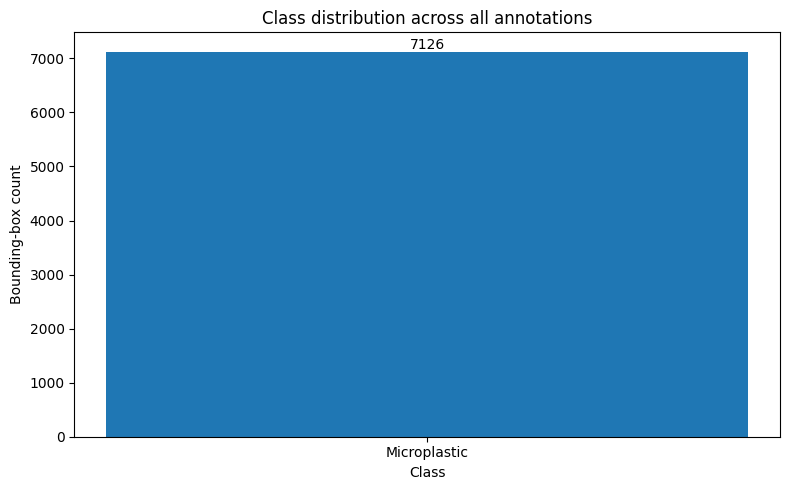

In [79]:
# Class distribution
class_distribution = clean_annotations.groupby(["split", "class"]).size().reset_index(name="annotation_count")
display(class_distribution)
class_distribution.to_csv(METRICS_DIR / "eda_class_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
class_counts = clean_annotations["class"].value_counts()
ax.bar(class_counts.index.astype(str), class_counts.values)
ax.set_title("Class distribution across all annotations")
ax.set_xlabel("Class")
ax.set_ylabel("Bounding-box count")
for index, value in enumerate(class_counts.values):
    ax.text(index, value, str(value), ha="center", va="bottom")
save_current_figure("02_class_distribution.png")
plt.show()

,objects_per_image
count,781.000000
mean,9.124200
std,6.963361
min,1.000000
25%,4.000000
50%,7.000000
75%,12.000000
max,52.000000


Saved figure: /kaggle/working/microplastic_detection_outputs/figures/03_objects_per_image_distribution.png


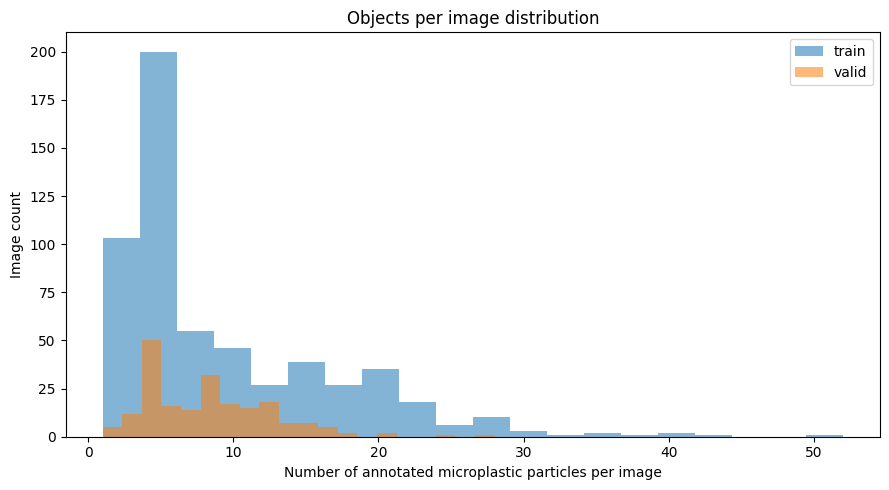

In [80]:
# Objects per image distribution
objects_per_image = clean_annotations.groupby(["split", "filename"]).size().reset_index(name="objects_per_image")
display(objects_per_image.describe())
objects_per_image.to_csv(METRICS_DIR / "eda_objects_per_image.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for split_name, split_data in objects_per_image.groupby("split"):
    ax.hist(split_data["objects_per_image"], bins=20, alpha=0.55, label=split_name)
ax.set_title("Objects per image distribution")
ax.set_xlabel("Number of annotated microplastic particles per image")
ax.set_ylabel("Image count")
ax.legend()
save_current_figure("03_objects_per_image_distribution.png")
plt.show()

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/04_bbox_size_distributions.png


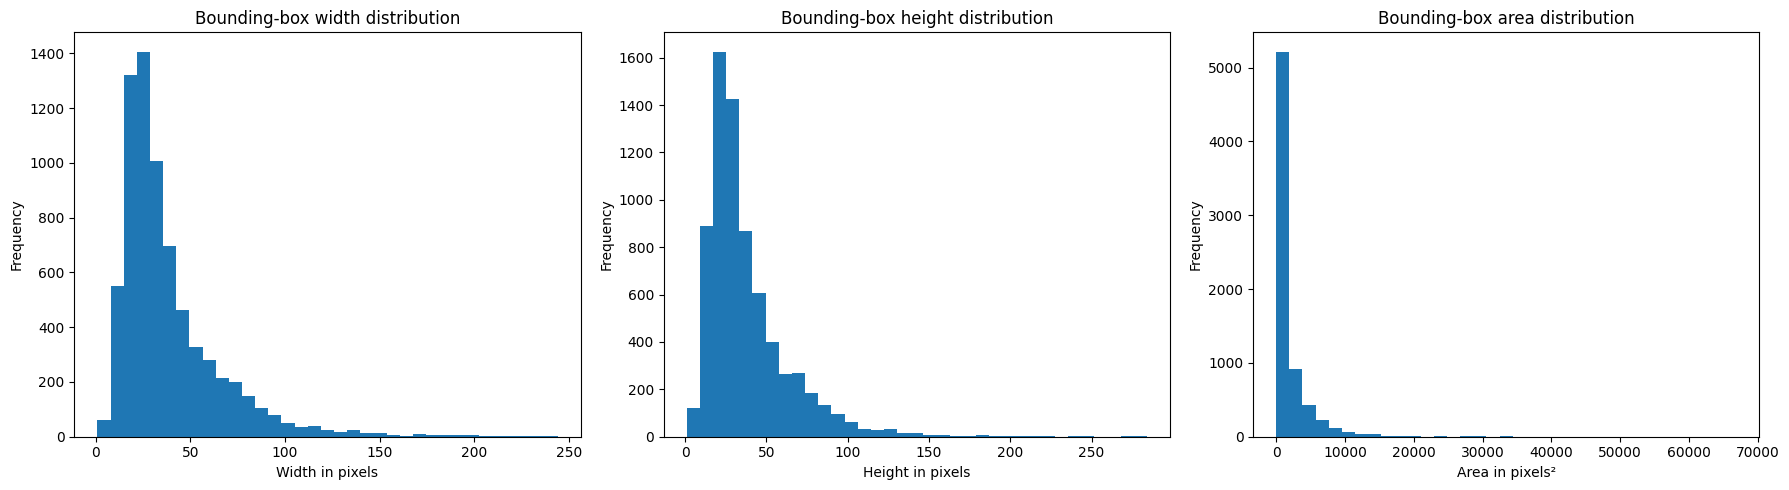

,count,mean,std,min,25%,50%,75%,max
bbox_width,7126.0,38.316166,27.261552,1.000000,21.000000,30.000000,47.000000,244.000000
bbox_height,7126.0,38.323463,26.353168,1.000000,22.000000,31.000000,47.000000,284.000000
bbox_area,7126.0,2042.279119,3593.919805,1.000000,462.000000,891.000000,2072.000000,66856.000000
bbox_area_ratio,7126.0,0.006821,0.012481,0.000003,0.001528,0.002947,0.006853,0.265159
bbox_aspect_ratio,7126.0,1.084728,0.590450,0.073171,0.785138,0.974026,1.206232,8.875000


In [81]:
# Bounding box width, height and area distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(clean_annotations["bbox_width"], bins=35)
axes[0].set_title("Bounding-box width distribution")
axes[0].set_xlabel("Width in pixels")
axes[0].set_ylabel("Frequency")

axes[1].hist(clean_annotations["bbox_height"], bins=35)
axes[1].set_title("Bounding-box height distribution")
axes[1].set_xlabel("Height in pixels")
axes[1].set_ylabel("Frequency")

axes[2].hist(clean_annotations["bbox_area"], bins=35)
axes[2].set_title("Bounding-box area distribution")
axes[2].set_xlabel("Area in pixels²")
axes[2].set_ylabel("Frequency")
save_current_figure("04_bbox_size_distributions.png")
plt.show()

bbox_summary = clean_annotations[["bbox_width", "bbox_height", "bbox_area", "bbox_area_ratio", "bbox_aspect_ratio"]].describe().T
bbox_summary.to_csv(METRICS_DIR / "eda_bbox_numeric_summary.csv")
display(bbox_summary)

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/05_bbox_aspect_and_area_ratio.png


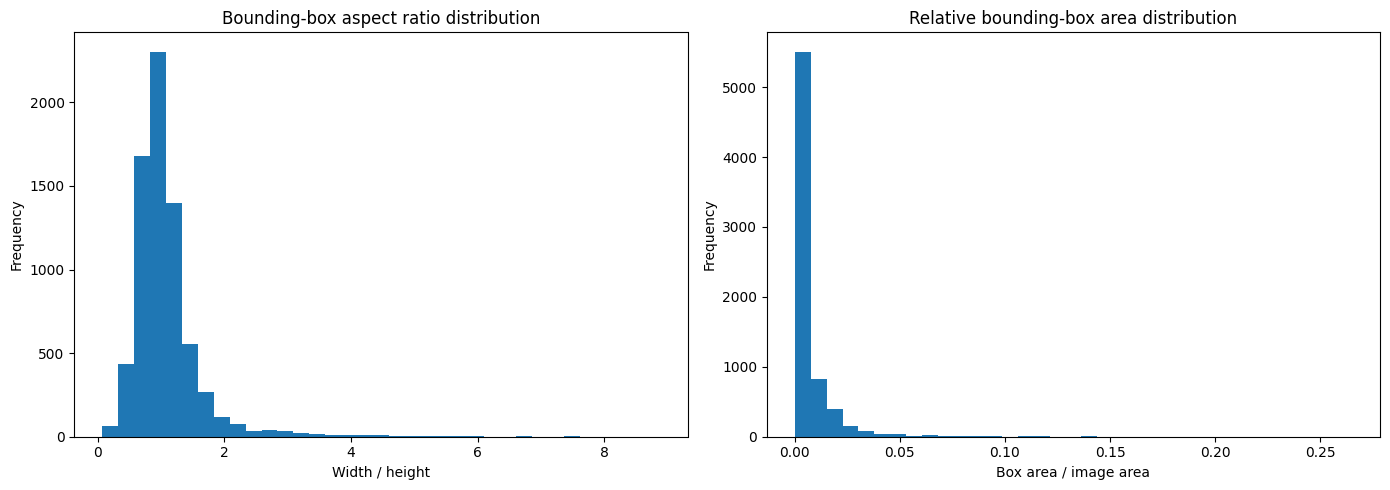

In [82]:
# Aspect ratio and relative size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clipped_aspect = clean_annotations["bbox_aspect_ratio"].replace([np.inf, -np.inf], np.nan).dropna().clip(upper=10)
axes[0].hist(clipped_aspect, bins=35)
axes[0].set_title("Bounding-box aspect ratio distribution")
axes[0].set_xlabel("Width / height")
axes[0].set_ylabel("Frequency")

axes[1].hist(clean_annotations["bbox_area_ratio"], bins=35)
axes[1].set_title("Relative bounding-box area distribution")
axes[1].set_xlabel("Box area / image area")
axes[1].set_ylabel("Frequency")
save_current_figure("05_bbox_aspect_and_area_ratio.png")
plt.show()

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/06_bbox_center_scatter.png


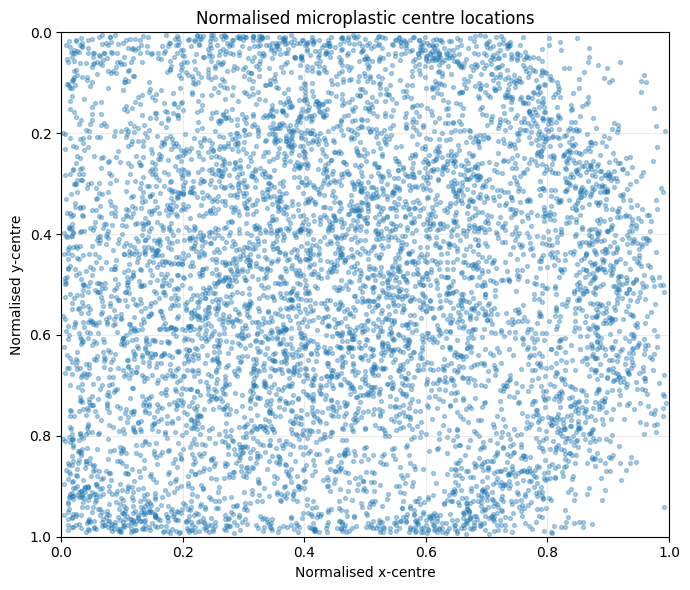

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/07_bbox_center_heatmap.png


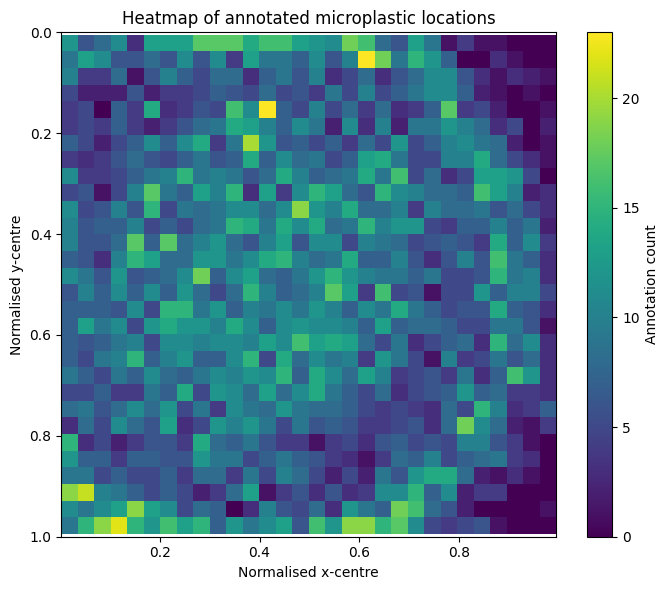

In [83]:
# Spatial distribution of object centres
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(clean_annotations["bbox_center_x_ratio"], clean_annotations["bbox_center_y_ratio"], s=8, alpha=0.35)
ax.set_title("Normalised microplastic centre locations")
ax.set_xlabel("Normalised x-centre")
ax.set_ylabel("Normalised y-centre")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
ax.grid(True, alpha=0.25)
save_current_figure("06_bbox_center_scatter.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
heatmap = ax.hist2d(
    clean_annotations["bbox_center_x_ratio"],
    clean_annotations["bbox_center_y_ratio"],
    bins=30
)
ax.set_title("Heatmap of annotated microplastic locations")
ax.set_xlabel("Normalised x-centre")
ax.set_ylabel("Normalised y-centre")
ax.set_ylim(1, 0)
plt.colorbar(heatmap[3], ax=ax, label="Annotation count")
save_current_figure("07_bbox_center_heatmap.png")
plt.show()

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/08_image_dimension_scatter.png


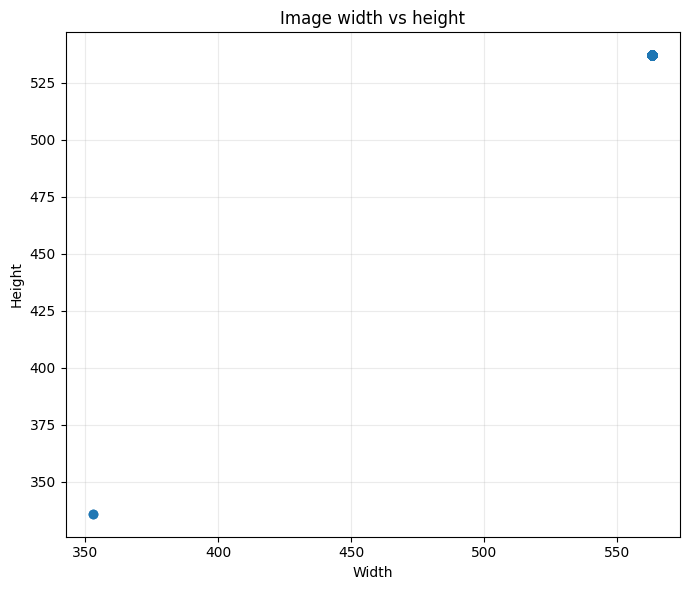

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/09_top_dense_images.png


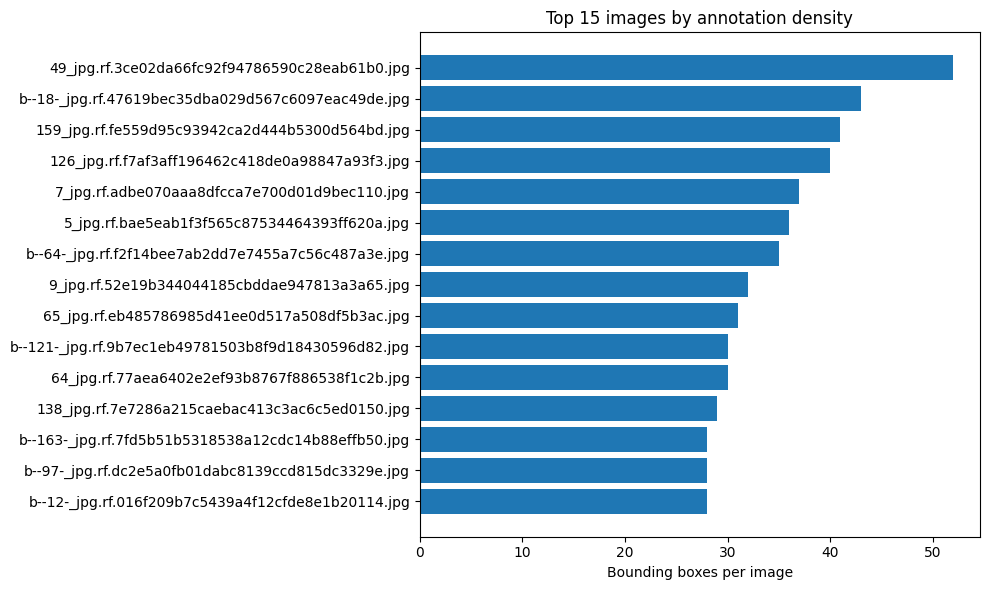

In [84]:
# Image dimensions and dense-image check
image_dimension_summary = clean_annotations.groupby(["split", "filename"]).agg(
    width=("width", "first"),
    height=("height", "first"),
    objects=("filename", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(image_dimension_summary["width"], image_dimension_summary["height"], s=35, alpha=0.7)
ax.set_title("Image width vs height")
ax.set_xlabel("Width")
ax.set_ylabel("Height")
ax.grid(True, alpha=0.25)
save_current_figure("08_image_dimension_scatter.png")
plt.show()

most_dense_images = image_dimension_summary.sort_values("objects", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(most_dense_images["filename"], most_dense_images["objects"])
ax.invert_yaxis()
ax.set_title("Top 15 images by annotation density")
ax.set_xlabel("Bounding boxes per image")
save_current_figure("09_top_dense_images.png")
plt.show()

## 5. Visual inspection of raw and annotated samples

These figures help verify that the annotation CSV and image files match correctly before training.

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/10_sample_annotated_images.png


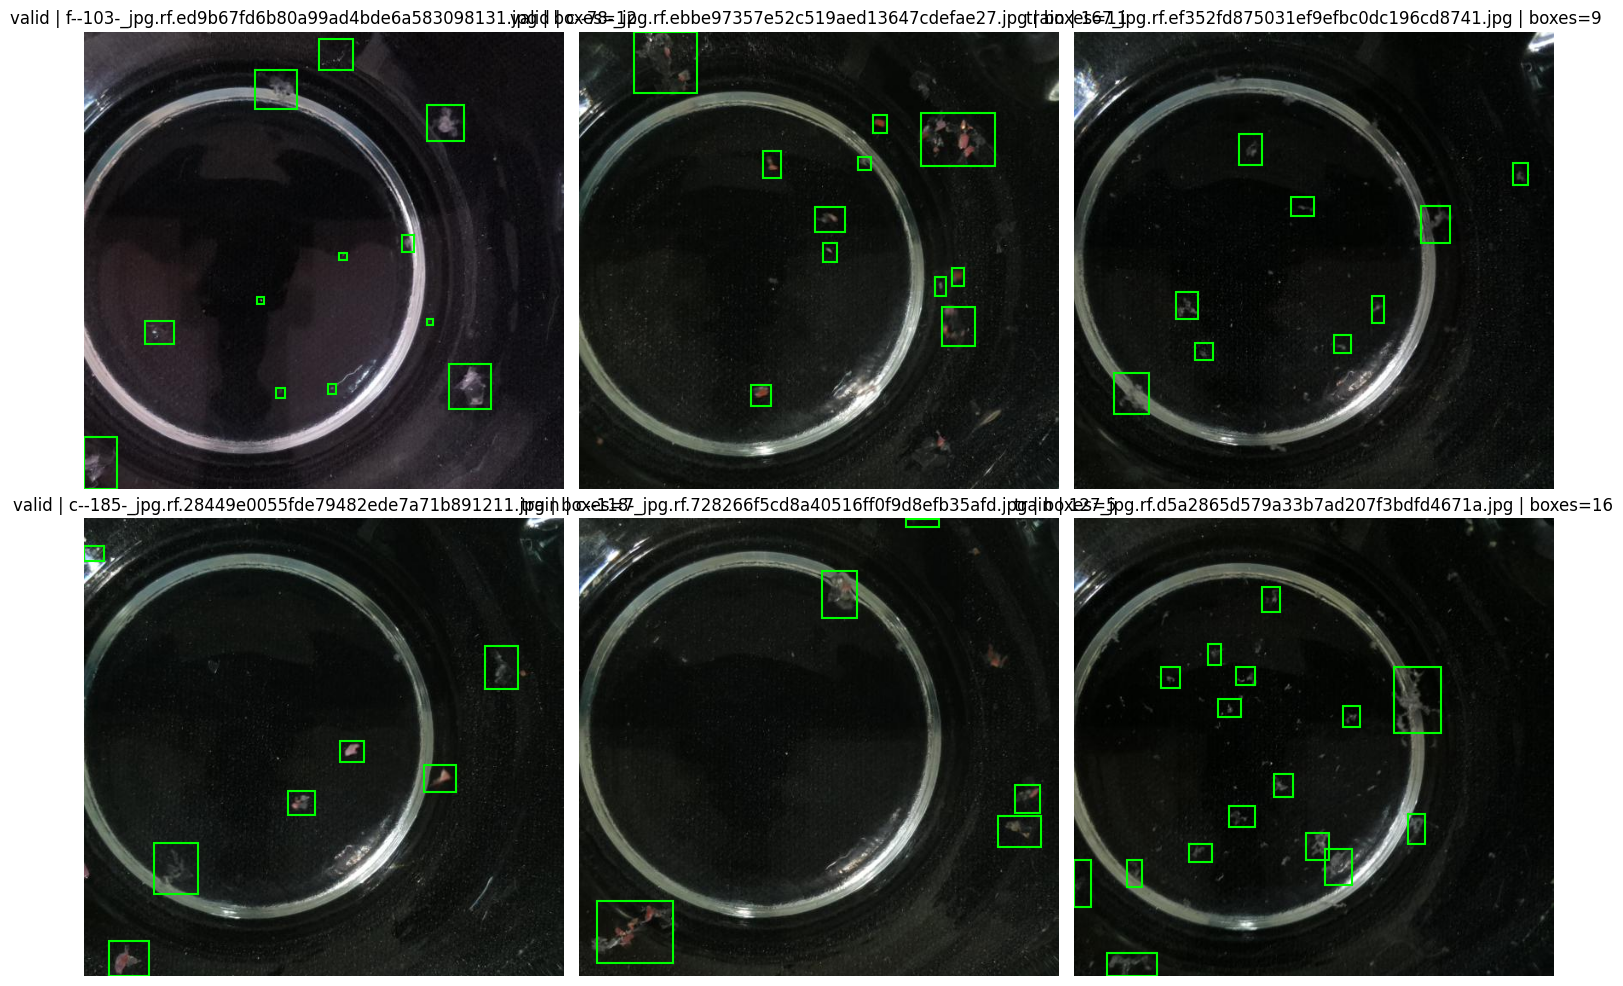

In [85]:
def draw_annotations_on_axis(ax, image: Image.Image, annotations: pd.DataFrame, title: str = "") -> None:
    ax.imshow(image)
    for _, row in annotations.iterrows():
        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["bbox_width"],
            row["bbox_height"],
            linewidth=1.5,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")


def show_annotated_samples(dataframe: pd.DataFrame, n_images: int = 6, split_name: Optional[str] = None) -> None:
    if split_name is not None:
        dataframe = dataframe[dataframe["split"] == split_name]
    unique_images = dataframe[["split", "filename", "image_path"]].drop_duplicates()
    sample_rows = unique_images.sample(min(n_images, len(unique_images)), random_state=CONFIG.random_seed)

    cols = 3
    rows = math.ceil(len(sample_rows) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, image_row) in zip(axes, sample_rows.iterrows()):
        image_path = image_row["image_path"]
        image = Image.open(image_path).convert("RGB")
        image_annotations = dataframe[(dataframe["split"] == image_row["split"]) & (dataframe["filename"] == image_row["filename"])]
        title = f"{image_row['split']} | {image_row['filename']} | boxes={len(image_annotations)}"
        draw_annotations_on_axis(ax, image, image_annotations, title=title)

    for ax in axes[len(sample_rows):]:
        ax.axis("off")
    save_current_figure("10_sample_annotated_images.png")
    plt.show()

show_annotated_samples(clean_annotations, n_images=6)

## 6. Detection dataset class and data loaders

The dataset class returns the format expected by `torchvision` detection models:

- `image`: tensor in `[C, H, W]`
- `target['boxes']`: `[N, 4]` tensor in `xyxy` format
- `target['labels']`: class labels, where `1 = Microplastic`
- `target['area']` and `target['iscrowd']`: useful for detection evaluation

In [86]:
# Make sure the cleaned annotation table exists before building PyTorch datasets.
if "clean_annotations" not in globals() or not isinstance(clean_annotations, pd.DataFrame):
    split_annotations = load_split_annotations(CONFIG.dataset_root)
    all_annotations = pd.concat(split_annotations.values(), ignore_index=True)
    clean_annotations, quality_summary = prepare_clean_annotations(all_annotations)

class DetectionTransform:
    """Simple image and box transform compatible with torchvision detection models."""

    def __init__(self, train: bool = False, horizontal_flip_probability: float = 0.5):
        self.train = train
        self.horizontal_flip_probability = horizontal_flip_probability

    def __call__(self, image: Image.Image, target: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        image_tensor = F.to_tensor(image)

        if self.train and random.random() < self.horizontal_flip_probability:
            _, image_height, image_width = image_tensor.shape
            image_tensor = F.hflip(image_tensor)
            boxes = target["boxes"].clone()
            old_xmin = boxes[:, 0].clone()
            old_xmax = boxes[:, 2].clone()
            boxes[:, 0] = image_width - old_xmax
            boxes[:, 2] = image_width - old_xmin
            target["boxes"] = boxes

        return image_tensor, target


class MicroplasticDetectionDataset(Dataset):
    """Roboflow-style CSV dataset for single-class microplastic detection."""

    def __init__(self, annotations: pd.DataFrame, transform: Optional[DetectionTransform] = None):
        self.annotations = annotations.copy().reset_index(drop=True)
        self.transform = transform
        self.image_index = (
            self.annotations[["split", "filename", "image_path", "width", "height"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        self.class_to_id = {CONFIG.class_name: 1}

    def __len__(self) -> int:
        return len(self.image_index)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        image_record = self.image_index.iloc[index]
        image_path = image_record["image_path"]
        filename = image_record["filename"]
        split_name = image_record["split"]

        image = Image.open(image_path).convert("RGB")
        image_width, image_height = image.size

        records = self.annotations[
            (self.annotations["split"] == split_name) &
            (self.annotations["filename"] == filename)
        ]

        boxes = records[["xmin", "ymin", "xmax", "ymax"]].values.astype(np.float32)
        boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, image_width)
        boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, image_height)

        labels = np.ones((len(boxes),), dtype=np.int64)
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = np.zeros((len(boxes),), dtype=np.int64)

        target: Dict[str, torch.Tensor] = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([index], dtype=torch.int64),
            "area": torch.as_tensor(area, dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64),
        }

        if self.transform is not None:
            image_tensor, target = self.transform(image, target)
        else:
            image_tensor = F.to_tensor(image)

        return image_tensor, target


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


def maybe_limit_dataset(dataset: Dataset, max_images: Optional[int]) -> Dataset:
    if max_images is None or max_images >= len(dataset):
        return dataset
    indices = list(range(max_images))
    return Subset(dataset, indices)

train_annotations = clean_annotations[clean_annotations["split"] == "train"].copy()
valid_annotations = clean_annotations[clean_annotations["split"].isin(["valid", "test"])].copy()

if train_annotations.empty:
    raise ValueError("No training annotations found.")
if valid_annotations.empty:
    raise ValueError("No validation/test annotations found.")

train_dataset_full = MicroplasticDetectionDataset(train_annotations, transform=DetectionTransform(train=True))
valid_dataset_full = MicroplasticDetectionDataset(valid_annotations, transform=DetectionTransform(train=False))

train_dataset = maybe_limit_dataset(train_dataset_full, CONFIG.max_train_images)
valid_dataset = maybe_limit_dataset(valid_dataset_full, CONFIG.max_valid_images)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=True,
    num_workers=CONFIG.num_workers,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
    # SSDLite uses BatchNorm layers, so the final incomplete training batch is dropped.
    # This avoids the error: expected more than 1 value per channel when training.
    drop_last=CONFIG.drop_last_train_batch,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=CONFIG.num_workers,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

print(f"Training images: {len(train_dataset):,}")
print(f"Validation images: {len(valid_dataset):,}")
print(f"Training DataLoader drop_last: {CONFIG.drop_last_train_batch}")

# Smoke-test one batch
images, targets = next(iter(train_loader))
print(f"Batch images: {len(images)}")
print(f"First image shape: {tuple(images[0].shape)}")
print(f"First target keys: {targets[0].keys()}")
print(f"First target boxes shape: {targets[0]['boxes'].shape}")

Training images: 577
Validation images: 204
Training DataLoader drop_last: True
Batch images: 2
First image shape: (3, 537, 563)
First target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
First target boxes shape: torch.Size([13, 4])


## 7. Professional model factory

The three selected models match the ethics/project plan because they compare different detection strategies:

- **Faster R-CNN ResNet50-FPN:** strong two-stage detector.
- **RetinaNet ResNet50-FPN:** one-stage detector with focal-loss design.
- **SSD/SSDLite MobileNetV3:** lightweight detector for lower-resource use.

The notebook attempts to use pretrained backbones for better feature extraction. If Kaggle cannot download weights, it falls back to training without pretrained backbones.

In [87]:
# Human-readable model names used in plots, metrics files and report tables.
MODEL_DISPLAY_NAMES = {
    "fasterrcnn_resnet50_fpn": "Faster R-CNN ResNet50-FPN",
    "retinanet_resnet50_fpn": "RetinaNet ResNet50-FPN",
    "ssdlite320_mobilenet_v3_large": "SSD/SSDLite MobileNetV3",
}

MODEL_NAMES = list(MODEL_DISPLAY_NAMES.keys())


def build_detection_model(model_name: str, num_classes: int, use_pretrained_backbone: bool = True) -> nn.Module:
    """Create a torchvision detection model with a single microplastic class + background."""
    print(f"\nBuilding model: {MODEL_DISPLAY_NAMES.get(model_name, model_name)}")

    try:
        # Build each model with one foreground class plus background.
        if model_name == "fasterrcnn_resnet50_fpn":
            weights_backbone = ResNet50_Weights.DEFAULT if use_pretrained_backbone else None
            model = fasterrcnn_resnet50_fpn(
                weights=None,
                weights_backbone=weights_backbone,
                num_classes=num_classes,
                min_size=512,
                max_size=768,
            )
        elif model_name == "retinanet_resnet50_fpn":
            weights_backbone = ResNet50_Weights.DEFAULT if use_pretrained_backbone else None
            model = retinanet_resnet50_fpn(
                weights=None,
                weights_backbone=weights_backbone,
                num_classes=num_classes,
                min_size=512,
                max_size=768,
            )
        elif model_name == "ssdlite320_mobilenet_v3_large":
            weights_backbone = MobileNet_V3_Large_Weights.DEFAULT if use_pretrained_backbone else None
            model = ssdlite320_mobilenet_v3_large(
                weights=None,
                weights_backbone=weights_backbone,
                num_classes=num_classes,
            )
        else:
            raise ValueError(f"Unsupported model name: {model_name}")
    except Exception as error:
        # If Kaggle cannot download pretrained backbones, continue with random initialisation.
        print(f"Pretrained-backbone model creation failed: {error}")
        print("Falling back to randomly initialized model.")
        if model_name == "fasterrcnn_resnet50_fpn":
            model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None, num_classes=num_classes, min_size=512, max_size=768)
        elif model_name == "retinanet_resnet50_fpn":
            model = retinanet_resnet50_fpn(weights=None, weights_backbone=None, num_classes=num_classes, min_size=512, max_size=768)
        elif model_name == "ssdlite320_mobilenet_v3_large":
            model = ssdlite320_mobilenet_v3_large(weights=None, weights_backbone=None, num_classes=num_classes)
        else:
            raise

    return model


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

# Optional quick model-factory check without training
factory_check_rows = []
for name in MODEL_NAMES:
    temporary_model = build_detection_model(name, CONFIG.num_classes, CONFIG.use_pretrained_backbone)
    factory_check_rows.append({
        "model_name": MODEL_DISPLAY_NAMES[name],
        "trainable_parameters": count_trainable_parameters(temporary_model),
    })
    del temporary_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

factory_check_df = pd.DataFrame(factory_check_rows)
display(factory_check_df)
factory_check_df.to_csv(METRICS_DIR / "model_parameter_summary.csv", index=False)


Building model: Faster R-CNN ResNet50-FPN

Building model: RetinaNet ResNet50-FPN

Building model: SSD/SSDLite MobileNetV3


,model_name,trainable_parameters
0,Faster R-CNN ResNet50-FPN,41076761
1,RetinaNet ResNet50-FPN,31946294
2,SSD/SSDLite MobileNetV3,3708680


## 8. Detection metrics

The evaluation uses per-image matching between predicted and ground-truth boxes. A prediction is treated as a true positive when it matches an unused ground-truth box with IoU ≥ `CONFIG.iou_threshold` and score ≥ `CONFIG.score_threshold`.

In [88]:
def move_targets_to_device(targets: List[Dict[str, torch.Tensor]], device: torch.device) -> List[Dict[str, torch.Tensor]]:
    return [{key: value.to(device) for key, value in target.items()} for target in targets]


def greedy_match_image(
    predicted_boxes: torch.Tensor,
    predicted_scores: torch.Tensor,
    ground_truth_boxes: torch.Tensor,
    score_threshold: float,
    iou_threshold: float,
) -> Dict[str, float]:
    """Greedy IoU matching for one image."""
    if predicted_boxes.numel() == 0:
        predicted_boxes = torch.empty((0, 4), dtype=torch.float32)
    if ground_truth_boxes.numel() == 0:
        ground_truth_boxes = torch.empty((0, 4), dtype=torch.float32)

    keep_mask = predicted_scores >= score_threshold if predicted_scores.numel() else torch.zeros((0,), dtype=torch.bool)
    predicted_boxes = predicted_boxes[keep_mask].cpu()
    predicted_scores = predicted_scores[keep_mask].cpu()

    if len(predicted_scores) > 0:
        order = torch.argsort(predicted_scores, descending=True)
        predicted_boxes = predicted_boxes[order]
        predicted_scores = predicted_scores[order]

    if len(predicted_boxes) == 0 and len(ground_truth_boxes) == 0:
        return {"tp": 0, "fp": 0, "fn": 0, "matched_iou_sum": 0.0, "matched_count": 0, "prediction_count": 0, "ground_truth_count": 0}
    if len(predicted_boxes) == 0:
        return {"tp": 0, "fp": 0, "fn": len(ground_truth_boxes), "matched_iou_sum": 0.0, "matched_count": 0, "prediction_count": 0, "ground_truth_count": len(ground_truth_boxes)}
    if len(ground_truth_boxes) == 0:
        return {"tp": 0, "fp": len(predicted_boxes), "fn": 0, "matched_iou_sum": 0.0, "matched_count": 0, "prediction_count": len(predicted_boxes), "ground_truth_count": 0}

    iou_matrix = box_iou(predicted_boxes, ground_truth_boxes.cpu())
    matched_ground_truth = set()
    true_positive = 0
    matched_iou_sum = 0.0

    for prediction_index in range(len(predicted_boxes)):
        candidate_ious = iou_matrix[prediction_index]
        best_iou = 0.0
        best_gt_index = -1
        for gt_index, iou_value in enumerate(candidate_ious):
            if gt_index in matched_ground_truth:
                continue
            if float(iou_value) > best_iou:
                best_iou = float(iou_value)
                best_gt_index = gt_index
        if best_iou >= iou_threshold and best_gt_index >= 0:
            true_positive += 1
            matched_iou_sum += best_iou
            matched_ground_truth.add(best_gt_index)

    false_positive = len(predicted_boxes) - true_positive
    false_negative = len(ground_truth_boxes) - true_positive

    return {
        "tp": true_positive,
        "fp": false_positive,
        "fn": false_negative,
        "matched_iou_sum": matched_iou_sum,
        "matched_count": true_positive,
        "prediction_count": len(predicted_boxes),
        "ground_truth_count": len(ground_truth_boxes),
    }


def summarise_detection_counts(rows: List[Dict[str, float]]) -> Dict[str, float]:
    total_tp = sum(row["tp"] for row in rows)
    total_fp = sum(row["fp"] for row in rows)
    total_fn = sum(row["fn"] for row in rows)
    total_predictions = sum(row["prediction_count"] for row in rows)
    total_ground_truths = sum(row["ground_truth_count"] for row in rows)
    matched_iou_sum = sum(row["matched_iou_sum"] for row in rows)
    matched_count = sum(row["matched_count"] for row in rows)

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    f1_score = 2 * precision * recall / (precision + recall + 1e-9)
    mean_matched_iou = matched_iou_sum / (matched_count + 1e-9)
    count_mae = np.mean([abs(row["prediction_count"] - row["ground_truth_count"]) for row in rows]) if rows else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "mean_matched_iou": mean_matched_iou,
        "count_mae": count_mae,
        "true_positives": total_tp,
        "false_positives": total_fp,
        "false_negatives": total_fn,
        "prediction_count": total_predictions,
        "ground_truth_count": total_ground_truths,
    }


def evaluate_detection_model(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    score_threshold: float,
    iou_threshold: float,
) -> Tuple[Dict[str, float], pd.DataFrame]:
    model.eval()
    rows: List[Dict[str, float]] = []

    with torch.no_grad():
        for batch_index, (images, targets) in enumerate(data_loader):
            images = [image.to(device) for image in images]
            outputs = model(images)

            for image_offset, (output, target) in enumerate(zip(outputs, targets)):
                match_summary = greedy_match_image(
                    predicted_boxes=output.get("boxes", torch.empty((0, 4))).detach().cpu(),
                    predicted_scores=output.get("scores", torch.empty((0,))).detach().cpu(),
                    ground_truth_boxes=target["boxes"].detach().cpu(),
                    score_threshold=score_threshold,
                    iou_threshold=iou_threshold,
                )
                row = {
                    "batch_index": batch_index,
                    "image_index_in_batch": image_offset,
                    **match_summary,
                }
                rows.append(row)

    per_image_df = pd.DataFrame(rows)
    metrics = summarise_detection_counts(rows)
    return metrics, per_image_df


def compute_optional_map(model: nn.Module, data_loader: DataLoader, device: torch.device) -> Optional[Dict[str, float]]:
    """Compute mAP if torchmetrics and its dependencies are available."""
    try:
        from torchmetrics.detection.mean_ap import MeanAveragePrecision
    except Exception as error:
        print(f"torchmetrics mAP not available: {error}")
        return None

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    model.eval()
    with torch.no_grad():
        for images, targets in data_loader:
            images = [image.to(device) for image in images]
            outputs = model(images)
            predictions = []
            references = []
            for output, target in zip(outputs, targets):
                predictions.append({
                    "boxes": output["boxes"].detach().cpu(),
                    "scores": output["scores"].detach().cpu(),
                    "labels": output["labels"].detach().cpu(),
                })
                references.append({
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                })
            metric.update(predictions, references)
    output = metric.compute()
    return {key: float(value) for key, value in output.items() if torch.is_tensor(value) and value.numel() == 1}

## 9. Training loop

This section trains each detector with the same dataset and evaluation logic. The SSD/SSDLite model needs one extra stability guard because its MobileNetV3 backbone contains BatchNorm layers. With small object-detection batches, a final batch of size one can create the PyTorch error `Expected more than 1 value per channel when training`. The notebook prevents this by dropping incomplete training batches and keeping SSDLite BatchNorm layers in evaluation mode while the rest of the model trains.


In [89]:
BATCH_NORM_LAYER_TYPES = (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d, nn.SyncBatchNorm)


def keep_batch_norm_layers_in_eval_mode(model: nn.Module) -> None:
    """Keep BatchNorm layers stable when training detection models with small batches."""
    for module in model.modules():
        if isinstance(module, BATCH_NORM_LAYER_TYPES):
            module.eval()


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    keep_batch_norm_eval: bool = False,
) -> float:
    """Train one full pass over the training loader and return the average loss."""
    model.train()

    # SSDLite/MobileNetV3 has BatchNorm layers that can fail on tiny final batches.
    # Keeping only BatchNorm layers in eval mode preserves running statistics while other layers train.
    if keep_batch_norm_eval:
        keep_batch_norm_layers_in_eval_mode(model)

    epoch_losses: List[float] = []

    for images, targets in data_loader:
        images = [image.to(device) for image in images]
        targets = move_targets_to_device(targets, device)

        # Torchvision detection models return a dictionary of loss components during training.
        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(total_loss):
            print(f"Non-finite loss detected: {total_loss}. Skipping this batch.")
            continue

        # Backpropagate the detection loss and clip gradients for stable training.
        optimizer.zero_grad(set_to_none=True)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_losses.append(float(total_loss.detach().cpu()))

    return float(np.mean(epoch_losses)) if epoch_losses else float("nan")


def train_single_model(model_name: str) -> Dict[str, Any]:
    """Train one selected detection model and return its final validation metrics."""
    set_global_seed(CONFIG.random_seed)
    display_name = MODEL_DISPLAY_NAMES[model_name]
    model_output_dir = MODELS_DIR / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    model = build_detection_model(model_name, CONFIG.num_classes, CONFIG.use_pretrained_backbone).to(DEVICE)

    # SSDLite requires BatchNorm protection on small Kaggle batches; Faster R-CNN and RetinaNet do not need it.
    keep_batch_norm_eval = bool(CONFIG.freeze_batch_norm_for_ssdlite and model_name == "ssdlite320_mobilenet_v3_large")
    if keep_batch_norm_eval:
        keep_batch_norm_layers_in_eval_mode(model)
        print("BatchNorm stability guard enabled for SSD/SSDLite MobileNetV3.")

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(2, CONFIG.epochs_per_model // 2), gamma=0.5)

    training_history: List[Dict[str, Any]] = []
    best_f1 = -1.0
    best_checkpoint_path = model_output_dir / f"{model_name}_best.pth"

    print(f"\nStarting training: {display_name}")
    print("Training progress will be reported after each epoch.")
    print(f"Trainable parameters: {count_trainable_parameters(model):,}")

    start_time = time.time()
    for epoch in range(1, CONFIG.epochs_per_model + 1):
        epoch_start_time = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, keep_batch_norm_eval=keep_batch_norm_eval)
        scheduler.step()

        # Evaluate after each epoch so the best checkpoint can be selected using validation F1-score.
        validation_metrics, validation_per_image = evaluate_detection_model(
            model=model,
            data_loader=valid_loader,
            device=DEVICE,
            score_threshold=CONFIG.score_threshold,
            iou_threshold=CONFIG.iou_threshold,
        )

        epoch_record = {
            "model_name": model_name,
            "model_display_name": display_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_seconds": time.time() - epoch_start_time,
            **validation_metrics,
        }
        training_history.append(epoch_record)

        print(
            f"Epoch {epoch:02d}/{CONFIG.epochs_per_model} | "
            f"loss={train_loss:.4f} | "
            f"precision={validation_metrics['precision']:.4f} | "
            f"recall={validation_metrics['recall']:.4f} | "
            f"f1={validation_metrics['f1_score']:.4f} | "
            f"IoU={validation_metrics['mean_matched_iou']:.4f} | "
            f"count MAE={validation_metrics['count_mae']:.2f}"
        )

        if CONFIG.save_every_epoch:
            torch.save(model.state_dict(), model_output_dir / f"{model_name}_epoch_{epoch:02d}.pth")

        if validation_metrics["f1_score"] > best_f1:
            best_f1 = validation_metrics["f1_score"]
            torch.save(model.state_dict(), best_checkpoint_path)
            validation_per_image.to_csv(METRICS_DIR / f"{model_name}_best_per_image_metrics.csv", index=False)

    total_seconds = time.time() - start_time
    history_df = pd.DataFrame(training_history)
    history_df.to_csv(METRICS_DIR / f"{model_name}_training_history.csv", index=False)

    # Load the best checkpoint before final evaluation. If training produced no valid checkpoint, report a clear error.
    if not best_checkpoint_path.exists():
        raise RuntimeError("No valid checkpoint was saved. Check whether all training batches produced non-finite losses.")
    model.load_state_dict(torch.load(best_checkpoint_path, map_location=DEVICE))
    final_metrics, final_per_image = evaluate_detection_model(
        model=model,
        data_loader=valid_loader,
        device=DEVICE,
        score_threshold=CONFIG.score_threshold,
        iou_threshold=CONFIG.iou_threshold,
    )
    final_per_image.to_csv(METRICS_DIR / f"{model_name}_final_per_image_metrics.csv", index=False)

    map_metrics = compute_optional_map(model, valid_loader, DEVICE)
    if map_metrics:
        for key, value in map_metrics.items():
            final_metrics[f"map_{key}"] = value

    result = {
        "model_name": model_name,
        "model_display_name": display_name,
        "training_status": "completed",
        "best_checkpoint_path": str(best_checkpoint_path),
        "total_training_seconds": total_seconds,
        "trainable_parameters": count_trainable_parameters(model),
        **final_metrics,
    }

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


all_model_results: List[Dict[str, Any]] = []

models_to_train = MODEL_NAMES if CONFIG.train_all_models else ["fasterrcnn_resnet50_fpn"]

for selected_model_name in models_to_train:
    try:
        result = train_single_model(selected_model_name)
        all_model_results.append(result)
    except Exception as error:
        print(f"Training failed for {selected_model_name}: {error}")
        all_model_results.append({
            "model_name": selected_model_name,
            "model_display_name": MODEL_DISPLAY_NAMES.get(selected_model_name, selected_model_name),
            "training_status": "failed",
            "error": str(error),
        })

model_comparison_df = pd.DataFrame(all_model_results)
model_comparison_df.to_csv(METRICS_DIR / "model_comparison_metrics.csv", index=False)

display(model_comparison_df)


Building model: Faster R-CNN ResNet50-FPN

Starting training: Faster R-CNN ResNet50-FPN
Training progress will be reported after each epoch.
Trainable parameters: 41,076,761
Epoch 01/6 | loss=1.0226 | precision=0.4163 | recall=0.7102 | f1=0.5249 | IoU=0.6969 | count MAE=6.16
Epoch 02/6 | loss=0.8648 | precision=0.2764 | recall=0.8089 | f1=0.4120 | IoU=0.6934 | count MAE=16.06
Epoch 03/6 | loss=0.8063 | precision=0.4358 | recall=0.7925 | f1=0.5624 | IoU=0.6978 | count MAE=6.93
Epoch 04/6 | loss=0.7303 | precision=0.6022 | recall=0.7654 | f1=0.6741 | IoU=0.7209 | count MAE=3.16
Epoch 05/6 | loss=0.7080 | precision=0.5038 | recall=0.7895 | f1=0.6151 | IoU=0.6985 | count MAE=5.12
Epoch 06/6 | loss=0.6979 | precision=0.4853 | recall=0.7690 | f1=0.5951 | IoU=0.7181 | count MAE=5.26

Building model: RetinaNet ResNet50-FPN

Starting training: RetinaNet ResNet50-FPN
Training progress will be reported after each epoch.
Trainable parameters: 31,946,294
Epoch 01/6 | loss=12.0126 | precision=0.338

,model_name,model_display_name,training_status,best_checkpoint_path,total_training_seconds,trainable_parameters,precision,recall,f1_score,mean_matched_iou,...,map_map_large,map_mar_1,map_mar_10,map_mar_100,map_mar_small,map_mar_medium,map_mar_large,map_map_per_class,map_mar_100_per_class,map_classes
0,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,completed,/kaggle/working/microplastic_detection_outputs...,453.387970,41076761,0.602220,0.765432,0.674087,0.720889,...,0.557480,0.065550,0.356849,0.416402,0.320995,0.501316,0.600000,-1.0,-1.0,1.0
1,retinanet_resnet50_fpn,RetinaNet ResNet50-FPN,completed,/kaggle/working/microplastic_detection_outputs...,370.096194,31946294,0.824675,0.597296,0.692806,0.725552,...,0.584248,0.062904,0.334156,0.410406,0.292840,0.515550,0.632558,-1.0,-1.0,1.0
2,ssdlite320_mobilenet_v3_large,SSD/SSDLite MobileNetV3,completed,/kaggle/working/microplastic_detection_outputs...,121.517598,3708680,0.738462,0.112875,0.195818,0.745344,...,0.529423,0.034509,0.137449,0.214932,0.092354,0.315789,0.602326,-1.0,-1.0,1.0


## 10. Training and comparison visualisations

These charts are dissertation-ready model comparison figures.

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/11_training_loss_by_model.png


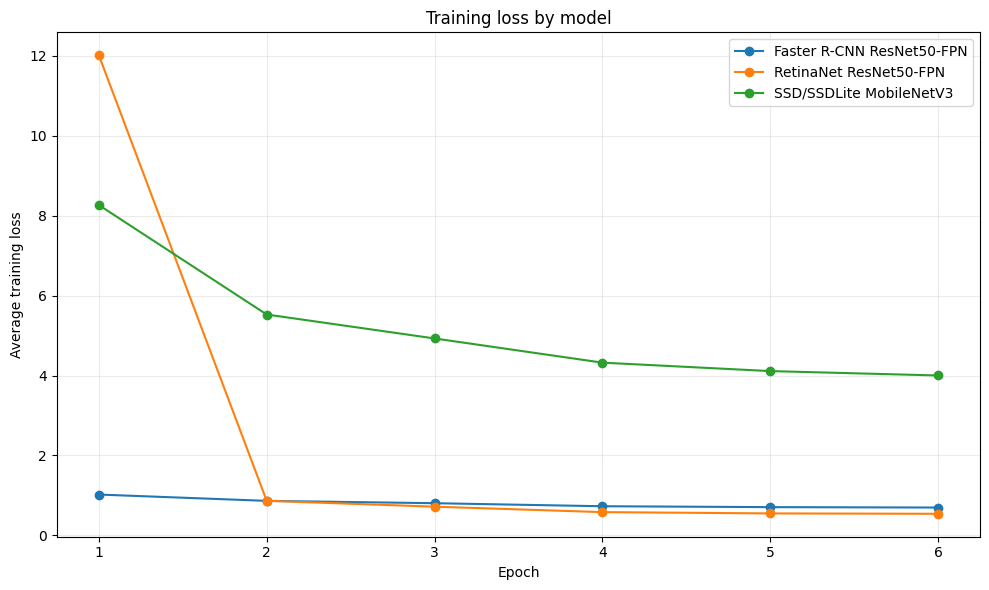

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/12_validation_f1_by_model.png


In [ ]:
def plot_training_histories() -> None:
    history_files = sorted(METRICS_DIR.glob("*_training_history.csv"))
    if not history_files:
        print("No training history files found.")
        return

    histories = [pd.read_csv(path) for path in history_files]
    history_df = pd.concat(histories, ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    for model_display_name, model_history in history_df.groupby("model_display_name"):
        ax.plot(model_history["epoch"], model_history["train_loss"], marker="o", label=model_display_name)
    ax.set_title("Training loss by model")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Average training loss")
    ax.legend()
    ax.grid(True, alpha=0.25)
    save_current_figure("11_training_loss_by_model.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    for model_display_name, model_history in history_df.groupby("model_display_name"):
        ax.plot(model_history["epoch"], model_history["f1_score"], marker="o", label=model_display_name)
    ax.set_title("Validation F1-score by model")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.25)
    save_current_figure("12_validation_f1_by_model.png")
    plt.show()

plot_training_histories()

In [ ]:
def plot_model_comparison(comparison_df: pd.DataFrame) -> None:
    numeric_df = comparison_df.dropna(subset=["precision", "recall", "f1_score"], how="all").copy()
    if numeric_df.empty:
        print("No successful model metrics available for plotting.")
        return

    metrics_to_plot = ["precision", "recall", "f1_score", "mean_matched_iou"]
    available_metrics = [metric for metric in metrics_to_plot if metric in numeric_df.columns]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(numeric_df))
    width = 0.18
    for i, metric in enumerate(available_metrics):
        ax.bar(x + (i - len(available_metrics) / 2) * width + width / 2, numeric_df[metric], width, label=metric)

    ax.set_xticks(x)
    ax.set_xticklabels(numeric_df["model_display_name"], rotation=20, ha="right")
    ax.set_title("Final model comparison")
    ax.set_ylabel("Metric value")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    save_current_figure("13_final_model_metric_comparison.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    sorted_df = numeric_df.sort_values("count_mae", ascending=True)
    ax.barh(sorted_df["model_display_name"], sorted_df["count_mae"])
    ax.set_title("Detection count error by model")
    ax.set_xlabel("Mean absolute error in object count")
    save_current_figure("14_detection_count_mae_by_model.png")
    plt.show()

plot_model_comparison(model_comparison_df)

Saved figure: /kaggle/working/microplastic_detection_outputs/figures/14_detection_count_mae_by_model.png


## 11. Score-threshold sensitivity analysis

A single confidence threshold may hide important trade-offs. This section evaluates how precision, recall and F1-score change when the prediction confidence threshold is varied.


Building model: RetinaNet ResNet50-FPN

Building model: SSD/SSDLite MobileNetV3


,model_name,model_display_name,score_threshold,precision,recall,f1_score,mean_matched_iou,count_mae,true_positives,false_positives,false_negatives,prediction_count,ground_truth_count
0,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.1,0.391158,0.821869,0.530047,0.716196,9.269608,1398,2176,303,3574,1701
1,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.2,0.507491,0.796590,0.619995,0.718576,5.142157,1355,1315,346,2670,1701
2,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.3,0.602220,0.765432,0.674087,0.720889,3.161765,1302,860,399,2162,1701
3,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.4,0.677838,0.737213,0.706280,0.721801,2.299020,1254,596,447,1850,1701
4,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.5,0.729927,0.705467,0.717489,0.724137,2.269608,1200,444,501,1644,1701
5,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.6,0.775908,0.677837,0.723564,0.726254,2.191176,1153,333,548,1486,1701
6,fasterrcnn_resnet50_fpn,Faster R-CNN ResNet50-FPN,0.7,0.809948,0.641387,0.715879,0.729025,2.470588,1091,256,610,1347,1701
7,retinanet_resnet50_fpn,RetinaNet ResNet50-FPN,0.1,0.417690,0.799530,0.548719,0.708068,7.720588,1360,1896,341,3256,1701
8,retinanet_resnet50_fpn,RetinaNet ResNet50-FPN,0.2,0.730983,0.694885,0.712477,0.715647,2.127451,1182,435,519,1617,1701
9,retinanet_resnet50_fpn,RetinaNet ResNet50-FPN,0.3,0.824675,0.597296,0.692806,0.725552,2.632353,1016,216,685,1232,1701


Saved figure: /kaggle/working/microplastic_detection_outputs/figures/15_threshold_sensitivity_f1.png


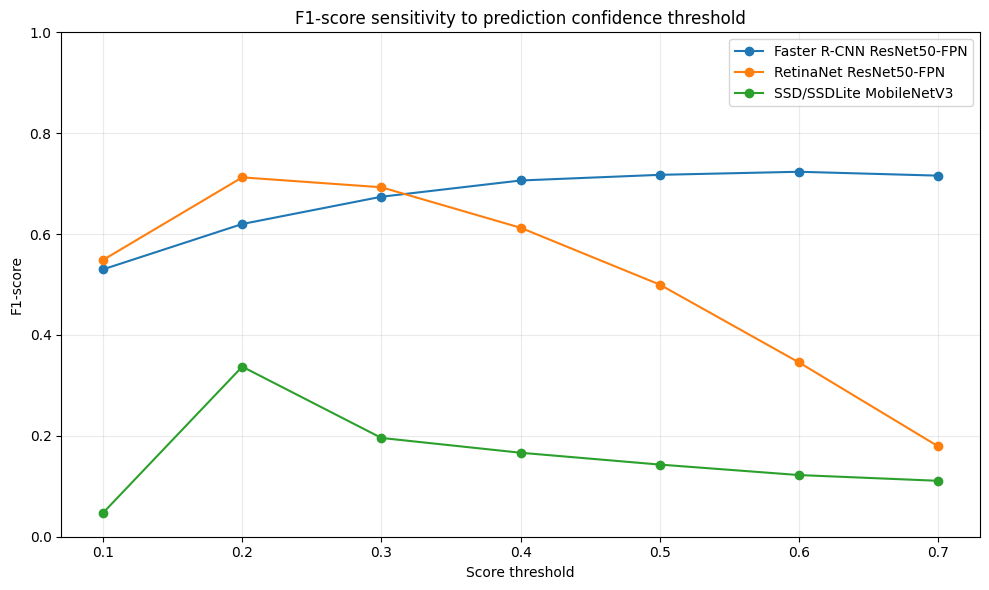

In [92]:
def load_trained_model(model_name: str, checkpoint_path: str) -> nn.Module:
    model = build_detection_model(model_name, CONFIG.num_classes, CONFIG.use_pretrained_backbone).to(DEVICE)
    state_dict = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def run_threshold_sweep(model_name: str, checkpoint_path: str, thresholds: List[float]) -> pd.DataFrame:
    model = load_trained_model(model_name, checkpoint_path)
    rows = []
    for threshold in thresholds:
        metrics, _ = evaluate_detection_model(
            model=model,
            data_loader=valid_loader,
            device=DEVICE,
            score_threshold=threshold,
            iou_threshold=CONFIG.iou_threshold,
        )
        rows.append({"model_name": model_name, "model_display_name": MODEL_DISPLAY_NAMES[model_name], "score_threshold": threshold, **metrics})
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)

successful_results = model_comparison_df.dropna(subset=["best_checkpoint_path"]).copy()
threshold_sweep_frames = []
threshold_values = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for _, result_row in successful_results.iterrows():
    threshold_sweep_frames.append(run_threshold_sweep(result_row["model_name"], result_row["best_checkpoint_path"], threshold_values))

if threshold_sweep_frames:
    threshold_sweep_df = pd.concat(threshold_sweep_frames, ignore_index=True)
    threshold_sweep_df.to_csv(METRICS_DIR / "threshold_sensitivity_analysis.csv", index=False)
    display(threshold_sweep_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    for model_display_name, model_data in threshold_sweep_df.groupby("model_display_name"):
        ax.plot(model_data["score_threshold"], model_data["f1_score"], marker="o", label=model_display_name)
    ax.set_title("F1-score sensitivity to prediction confidence threshold")
    ax.set_xlabel("Score threshold")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.25)
    save_current_figure("15_threshold_sensitivity_f1.png")
    plt.show()
else:
    print("No successful trained models available for threshold sweep.")

## 12. Prediction visualisation: actual vs predicted bounding boxes

The visual comparison below shows whether the model is locating microplastic particles in the expected regions.

Best model selected for visualisation: RetinaNet ResNet50-FPN

Building model: RetinaNet ResNet50-FPN
Saved figure: /kaggle/working/microplastic_detection_outputs/figures/16_best_model_predictions_vs_ground_truth.png


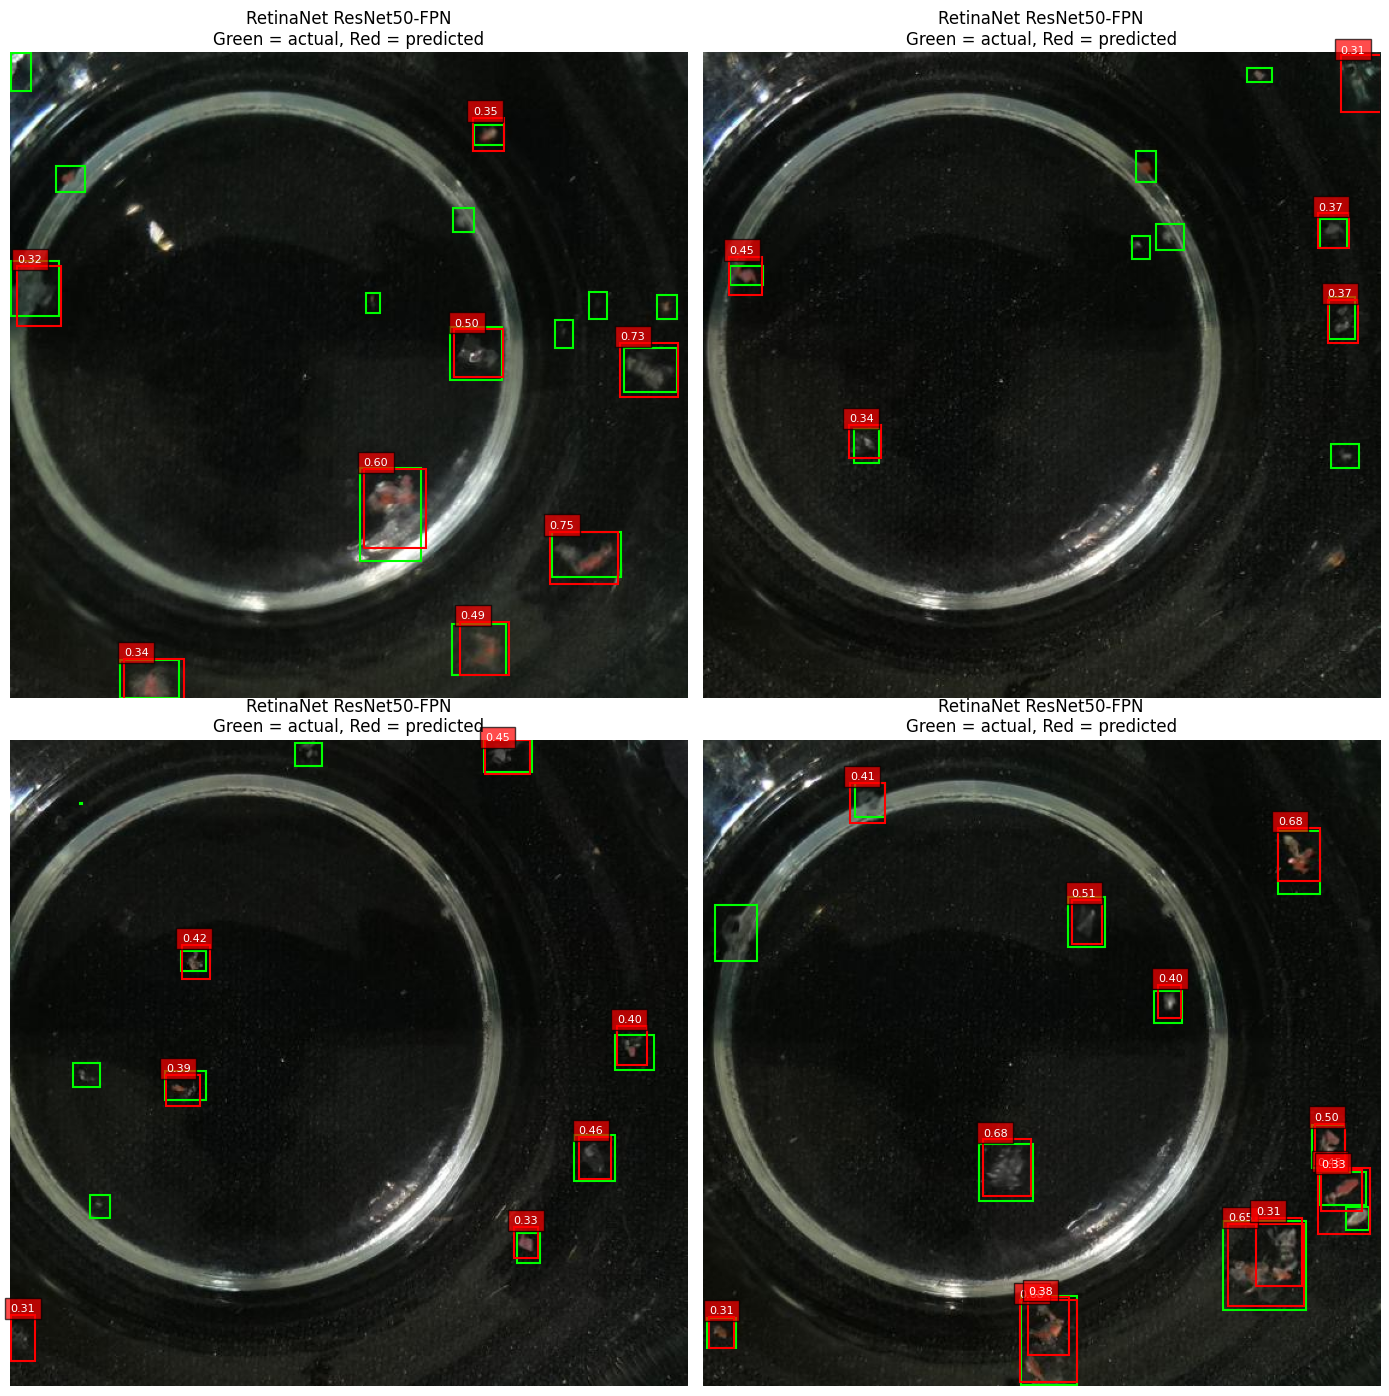

In [93]:
def select_best_model_row(comparison_df: pd.DataFrame) -> Optional[pd.Series]:
    success_df = comparison_df.dropna(subset=["f1_score", "best_checkpoint_path"]).copy()
    if success_df.empty:
        return None
    return success_df.sort_values("f1_score", ascending=False).iloc[0]


def plot_prediction_vs_ground_truth(
    model: nn.Module,
    dataset: Dataset,
    sample_indices: List[int],
    score_threshold: float,
    title_prefix: str,
    filename: str,
) -> None:
    cols = 2
    rows = math.ceil(len(sample_indices) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 7 * rows))
    axes = np.array(axes).reshape(-1)

    model.eval()
    for ax, sample_index in zip(axes, sample_indices):
        image_tensor, target = dataset[sample_index]
        with torch.no_grad():
            output = model([image_tensor.to(DEVICE)])[0]

        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        ax.imshow(image_np)

        # Ground truth boxes in lime
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)

        # Predicted boxes in red
        predicted_boxes = output["boxes"].detach().cpu()
        predicted_scores = output["scores"].detach().cpu()
        keep_indices = predicted_scores >= score_threshold
        for box, score in zip(predicted_boxes[keep_indices], predicted_scores[keep_indices]):
            x1, y1, x2, y2 = box.numpy()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, max(0, y1 - 3), f"{score:.2f}", color="white", fontsize=8, bbox=dict(facecolor="red", alpha=0.7))

        ax.set_title(f"{title_prefix}\nGreen = actual, Red = predicted")
        ax.axis("off")

    for ax in axes[len(sample_indices):]:
        ax.axis("off")

    save_current_figure(filename)
    plt.show()

best_model_row = select_best_model_row(model_comparison_df)
if best_model_row is not None:
    best_model_name = best_model_row["model_name"]
    best_checkpoint = best_model_row["best_checkpoint_path"]
    print(f"Best model selected for visualisation: {best_model_row['model_display_name']}")
    best_model = load_trained_model(best_model_name, best_checkpoint)

    available_indices = list(range(len(valid_dataset_full)))
    random.Random(CONFIG.random_seed).shuffle(available_indices)
    sample_indices = available_indices[:4]
    plot_prediction_vs_ground_truth(
        best_model,
        valid_dataset_full,
        sample_indices=sample_indices,
        score_threshold=CONFIG.score_threshold,
        title_prefix=best_model_row["model_display_name"],
        filename="16_best_model_predictions_vs_ground_truth.png",
    )
else:
    best_model = None
    print("No trained model available for prediction visualisation.")

## 13. Explainable AI: model-agnostic occlusion sensitivity

Because this is an object-detection project rather than a standard image-classification project, conventional Grad-CAM is less direct. This notebook therefore includes a **model-agnostic occlusion sensitivity map**. The method systematically masks small image regions and measures how much the top microplastic detection confidence changes.

Interpretation:

- High-impact regions suggest areas the detector depends on strongly.
- Low-impact regions suggest areas with limited influence on the top detection score.
- This is an explanatory visual aid, not a biological or environmental ground truth.

Running occlusion sensitivity explanation. This may take a few minutes.
Saved figure: /kaggle/working/microplastic_detection_outputs/figures/17_occlusion_sensitivity_xai.png


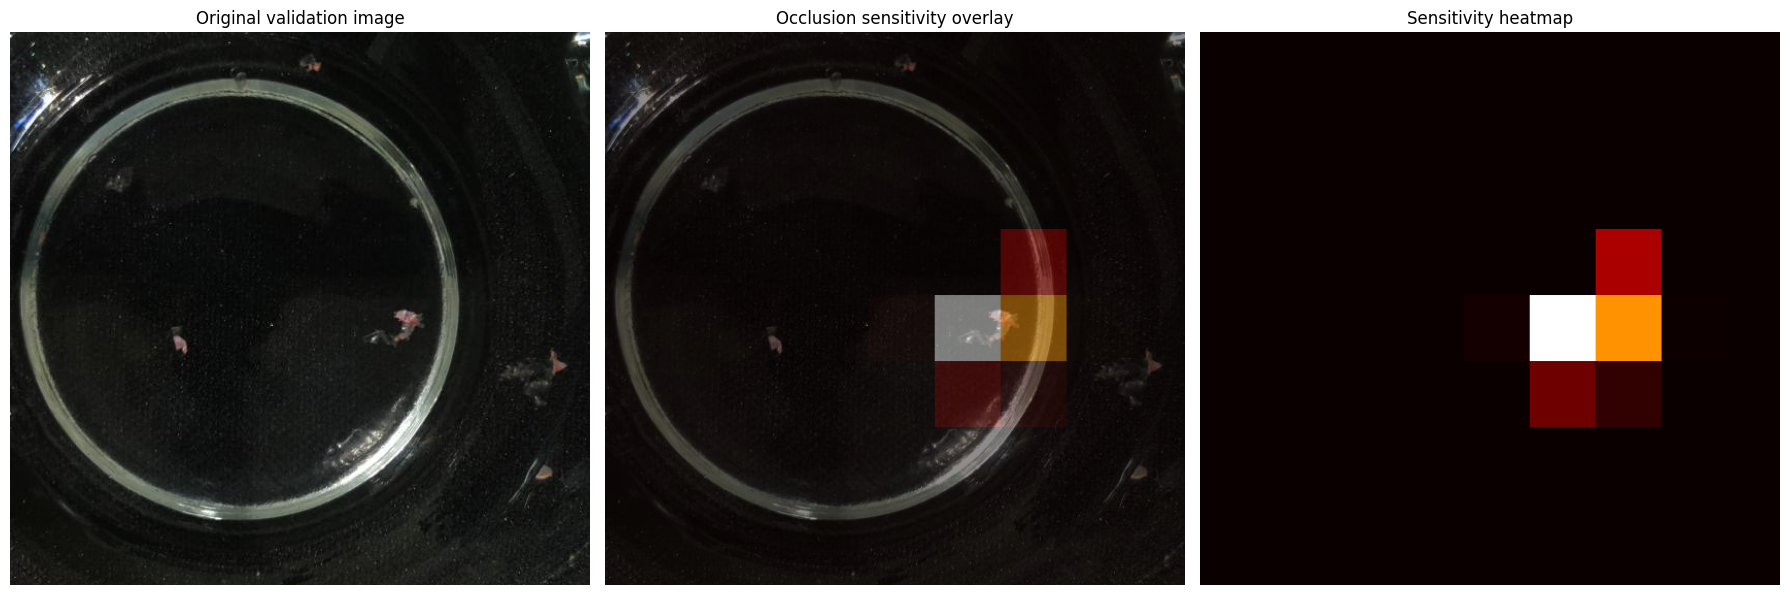

In [94]:
def detection_top_score(model: nn.Module, image_tensor: torch.Tensor) -> float:
    model.eval()
    with torch.no_grad():
        output = model([image_tensor.to(DEVICE)])[0]
    if len(output["scores"]) == 0:
        return 0.0
    return float(output["scores"].detach().cpu().max())


def create_occlusion_sensitivity_map(
    model: nn.Module,
    image_tensor: torch.Tensor,
    patch_size: int = 64,
    stride: int = 64,
) -> np.ndarray:
    """Create a simple model-agnostic sensitivity map for the top detection confidence."""
    baseline_score = detection_top_score(model, image_tensor)
    _, height, width = image_tensor.shape
    sensitivity = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)

    fill_values = image_tensor.mean(dim=(1, 2), keepdim=True)

    for y in range(0, height, stride):
        for x in range(0, width, stride):
            y2 = min(y + patch_size, height)
            x2 = min(x + patch_size, width)
            occluded_image = image_tensor.clone()
            occluded_image[:, y:y2, x:x2] = fill_values
            occluded_score = detection_top_score(model, occluded_image)
            score_drop = max(0.0, baseline_score - occluded_score)
            sensitivity[y:y2, x:x2] += score_drop
            counts[y:y2, x:x2] += 1

    sensitivity = sensitivity / np.maximum(counts, 1)
    if sensitivity.max() > sensitivity.min():
        sensitivity = (sensitivity - sensitivity.min()) / (sensitivity.max() - sensitivity.min())
    return sensitivity


def plot_occlusion_explanation(model: nn.Module, dataset: Dataset, sample_index: int, filename: str) -> None:
    image_tensor, target = dataset[sample_index]
    heatmap = create_occlusion_sensitivity_map(
        model,
        image_tensor,
        patch_size=CONFIG.xai_patch_size,
        stride=CONFIG.xai_stride,
    )
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(image_np)
    axes[0].set_title("Original validation image")
    axes[0].axis("off")

    axes[1].imshow(image_np)
    axes[1].imshow(heatmap, alpha=0.45, cmap="hot")
    axes[1].set_title("Occlusion sensitivity overlay")
    axes[1].axis("off")

    axes[2].imshow(heatmap, cmap="hot")
    axes[2].set_title("Sensitivity heatmap")
    axes[2].axis("off")

    save_current_figure(filename)
    plt.show()

if CONFIG.run_xai and best_model is not None:
    print("Running occlusion sensitivity explanation. This may take a few minutes.")
    plot_occlusion_explanation(best_model, valid_dataset_full, sample_index=0, filename="17_occlusion_sensitivity_xai.png")
else:
    print("XAI skipped because CONFIG.run_xai is False or no trained model is available.")

## 14. Final experiment report table

This section writes a compact final report summary for the dissertation and viva discussion.

In [95]:
def create_final_report_summary(comparison_df: pd.DataFrame) -> pd.DataFrame:
    if comparison_df.empty:
        return pd.DataFrame()

    report_columns = [
        "model_display_name",
        "training_status",
        "precision",
        "recall",
        "f1_score",
        "mean_matched_iou",
        "count_mae",
        "true_positives",
        "false_positives",
        "false_negatives",
        "prediction_count",
        "ground_truth_count",
        "trainable_parameters",
        "total_training_seconds",
        "best_checkpoint_path",
        "error",
    ]
    available_columns = [column for column in report_columns if column in comparison_df.columns]
    summary_df = comparison_df[available_columns].copy()

    numeric_columns = summary_df.select_dtypes(include=[np.number]).columns
    summary_df[numeric_columns] = summary_df[numeric_columns].round(4)
    return summary_df

final_summary_df = create_final_report_summary(model_comparison_df)
final_summary_df.to_csv(REPORTS_DIR / "final_model_report_summary.csv", index=False)
display(final_summary_df)

best_row = select_best_model_row(model_comparison_df)
if best_row is not None:
    print("\nBest model summary:")
    print(f"Model: {best_row['model_display_name']}")
    print(f"F1-score: {best_row['f1_score']:.4f}")
    print(f"Precision: {best_row['precision']:.4f}")
    print(f"Recall: {best_row['recall']:.4f}")
    print(f"Mean matched IoU: {best_row['mean_matched_iou']:.4f}")
    print(f"Best checkpoint: {best_row['best_checkpoint_path']}")

,model_display_name,training_status,precision,recall,f1_score,mean_matched_iou,count_mae,true_positives,false_positives,false_negatives,prediction_count,ground_truth_count,trainable_parameters,total_training_seconds,best_checkpoint_path
0,Faster R-CNN ResNet50-FPN,completed,0.6022,0.7654,0.6741,0.7209,3.1618,1302,860,399,2162,1701,41076761,453.3880,/kaggle/working/microplastic_detection_outputs...
1,RetinaNet ResNet50-FPN,completed,0.8247,0.5973,0.6928,0.7256,2.6324,1016,216,685,1232,1701,31946294,370.0962,/kaggle/working/microplastic_detection_outputs...
2,SSD/SSDLite MobileNetV3,completed,0.7385,0.1129,0.1958,0.7453,7.2500,192,68,1509,260,1701,3708680,121.5176,/kaggle/working/microplastic_detection_outputs...



Best model summary:
Model: RetinaNet ResNet50-FPN
F1-score: 0.6928
Precision: 0.8247
Recall: 0.5973
Mean matched IoU: 0.7256
Best checkpoint: /kaggle/working/microplastic_detection_outputs/models/retinanet_resnet50_fpn/retinanet_resnet50_fpn_best.pth


## 15. Export all outputs

Kaggle keeps files written to `/kaggle/working/`. This cell creates a ZIP file containing metrics, figures, reports and model checkpoints.

In [96]:
# Save project notes that can be cited in the final report
project_notes = {
    "project_title": "Comparative Explainable Deep Learning for Microplastic Detection and Localisation",
    "dataset_name": "Microplastic Dataset for Computer Vision",
    "dataset_url": "https://www.kaggle.com/datasets/imtkaggleteam/microplastic-dataset-for-computer-vision",
    "dataset_provider": "Panats MP Project",
    "ethical_scope": "Secondary data only; no human participants; no surveys; no interviews; no personal data; no human tissue or bodily fluids.",
    "task": "Single-class microplastic object detection and localisation using MPDS bounding boxes.",
    "models": MODEL_DISPLAY_NAMES,
    "primary_metrics": ["precision", "recall", "f1_score", "mean_matched_iou", "count_mae"],
}

with open(REPORTS_DIR / "project_notes.json", "w") as f:
    json.dump(project_notes, f, indent=4)

archive_base = str(CONFIG.output_root)
archive_path = shutil.make_archive(archive_base, "zip", CONFIG.output_root)
print(f"Created ZIP archive: {archive_path}")
print("Main files created:")
for path in sorted(CONFIG.output_root.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(CONFIG.output_root))

Created ZIP archive: /kaggle/working/microplastic_detection_outputs.zip
Main files created:
 - experiment_config.json
 - figures/01_split_summary.png
 - figures/02_class_distribution.png
 - figures/03_objects_per_image_distribution.png
 - figures/04_bbox_size_distributions.png
 - figures/05_bbox_aspect_and_area_ratio.png
 - figures/06_bbox_center_scatter.png
 - figures/07_bbox_center_heatmap.png
 - figures/08_image_dimension_scatter.png
 - figures/09_top_dense_images.png
 - figures/10_sample_annotated_images.png
 - figures/11_training_loss_by_model.png
 - figures/12_validation_f1_by_model.png
 - figures/13_final_model_metric_comparison.png
 - figures/14_detection_count_mae_by_model.png
 - figures/15_threshold_sensitivity_f1.png
 - figures/16_best_model_predictions_vs_ground_truth.png
 - figures/17_occlusion_sensitivity_xai.png
 - metrics/annotation_quality_summary.csv
 - metrics/clean_annotations_audit.csv
 - metrics/eda_bbox_numeric_summary.csv
 - metrics/eda_class_distribution.csv
 -

## 16. Final interpretation guide

Use the final results carefully:

- This project detects and localises **microplastic objects** using bounding-box annotations.
- The dataset contains one object class: **Microplastic**.
- Performance should be judged using detection metrics, not normal classification accuracy alone.
- A strong model should have balanced precision and recall, a good F1-score, reasonable IoU, and low detection-count error.
- XAI heatmaps are supportive interpretation visuals. They do not replace expert environmental validation.
- Since the study uses only secondary Kaggle data, the work remains aligned with the UREC form and does not involve human participants or personal data.